## 🏠**Real Estate - Training a Model**

### **The data is taken from Kaggle**


**The Housing dataset contains 14 attributes about neighborhoods. The goal is to predict **MEDV**, the median house price in $1000s.**


| **Feature** | **Description** |
|-------------|-----------------|
| **CRIM** | **Crime rate by town** |
| **ZN** | **Proportion of residential land zoned for lots over 25,000 sq.ft.** |
| **INDUS** | **Percentage of non-retail business acres per town** |
| **CHAS** | **Charles River dummy variable (1 if tract bounds river; 0 otherwise)** |
| **NOX** | **Nitric oxides concentration (pollution level)** |
| **RM** | **Average number of rooms per dwelling** |
| **AGE** | **Proportion of owner-occupied units built prior to 1940** |
| **DIS** | **Weighted distances to employment centers** |
| **RAD** | **Index of accessibility to radial highways** |
| **TAX** | **Property-tax rate per $10,000** |
| **PTRATIO** | **Pupil-teacher ratio by town** |
| **B** | **1000(Bk − 0.63)², where Bk is the proportion of black population** |
| **LSTAT** | **% lower-status population** |
| **MEDV** | **Median value of owner-occupied homes in $1000s ← this is your target / price** |


**Importing Necessary Libraries**

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
np.random.seed(42)
from sklearn.model_selection import train_test_split
from pandas.plotting import scatter_matrix
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [2]:
housing = pd.read_csv("data.csv")

In [3]:
housing.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,NaN,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,NaN,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,NaN,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
housing.tail()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
506,0.98765,0.0,12.5,0,0.561,6.980,89.0,2.098,3,320,23.0,396.0,12.0,12.0
507,0.23456,0.0,12.5,0,0.561,6.980,76.0,2.654,3,320,23.0,343.0,25.0,32.0
508,0.44433,0.0,12.5,0,0.561,6.123,98.0,2.987,3,320,23.0,343.0,21.0,54.0
509,0.77763,0.0,12.7,0,0.561,6.222,34.0,2.543,3,329,23.0,343.0,76.0,67.0
510,0.65432,0.0,12.8,0,0.561,6.760,67.0,2.987,3,345,23.0,321.0,45.0,24.0


In [5]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 511 entries, 0 to 510
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     511 non-null    float64
 1   ZN       511 non-null    float64
 2   INDUS    511 non-null    float64
 3   CHAS     511 non-null    int64  
 4   NOX      511 non-null    float64
 5   RM       502 non-null    float64
 6   AGE      511 non-null    float64
 7   DIS      511 non-null    float64
 8   RAD      511 non-null    int64  
 9   TAX      511 non-null    int64  
 10  PTRATIO  511 non-null    float64
 11  B        511 non-null    float64
 12  LSTAT    511 non-null    float64
 13  MEDV     511 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 56.0 KB


In [6]:
housing['CHAS'].value_counts()

CHAS
0    476
1     35
Name: count, dtype: int64

In [7]:
housing.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,511.000000,511.000000,511.000000,511.000000,511.000000,502.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000
mean,3.584139,11.252446,11.151096,0.068493,0.554757,6.284795,68.616243,3.783876,9.485323,407.440313,18.500000,356.600900,12.879550,22.682192
std,8.564433,23.234838,6.828175,0.252838,0.115310,0.704560,28.099130,2.098631,8.688469,167.903532,2.200348,90.882679,7.797416,9.484262
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082325,0.000000,5.190000,0.000000,0.449000,5.884250,45.050000,2.100350,4.000000,279.500000,17.400000,374.710000,7.065000,17.050000
50%,0.261690,0.000000,9.690000,0.000000,0.538000,6.208500,77.300000,3.152300,5.000000,330.000000,19.100000,391.340000,11.450000,21.200000
75%,3.621175,12.500000,18.100000,0.000000,0.624000,6.628000,94.050000,5.118000,24.000000,666.000000,20.200000,396.210000,17.105000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,23.000000,396.900000,76.000000,67.000000


### **Creating a Hist Figures**

array([[<Axes: title={'center': 'CRIM'}>, <Axes: title={'center': 'ZN'}>,
        <Axes: title={'center': 'INDUS'}>,
        <Axes: title={'center': 'CHAS'}>],
       [<Axes: title={'center': 'NOX'}>, <Axes: title={'center': 'RM'}>,
        <Axes: title={'center': 'AGE'}>, <Axes: title={'center': 'DIS'}>],
       [<Axes: title={'center': 'RAD'}>, <Axes: title={'center': 'TAX'}>,
        <Axes: title={'center': 'PTRATIO'}>,
        <Axes: title={'center': 'B'}>],
       [<Axes: title={'center': 'LSTAT'}>,
        <Axes: title={'center': 'MEDV'}>, <Axes: >, <Axes: >]],
      dtype=object)

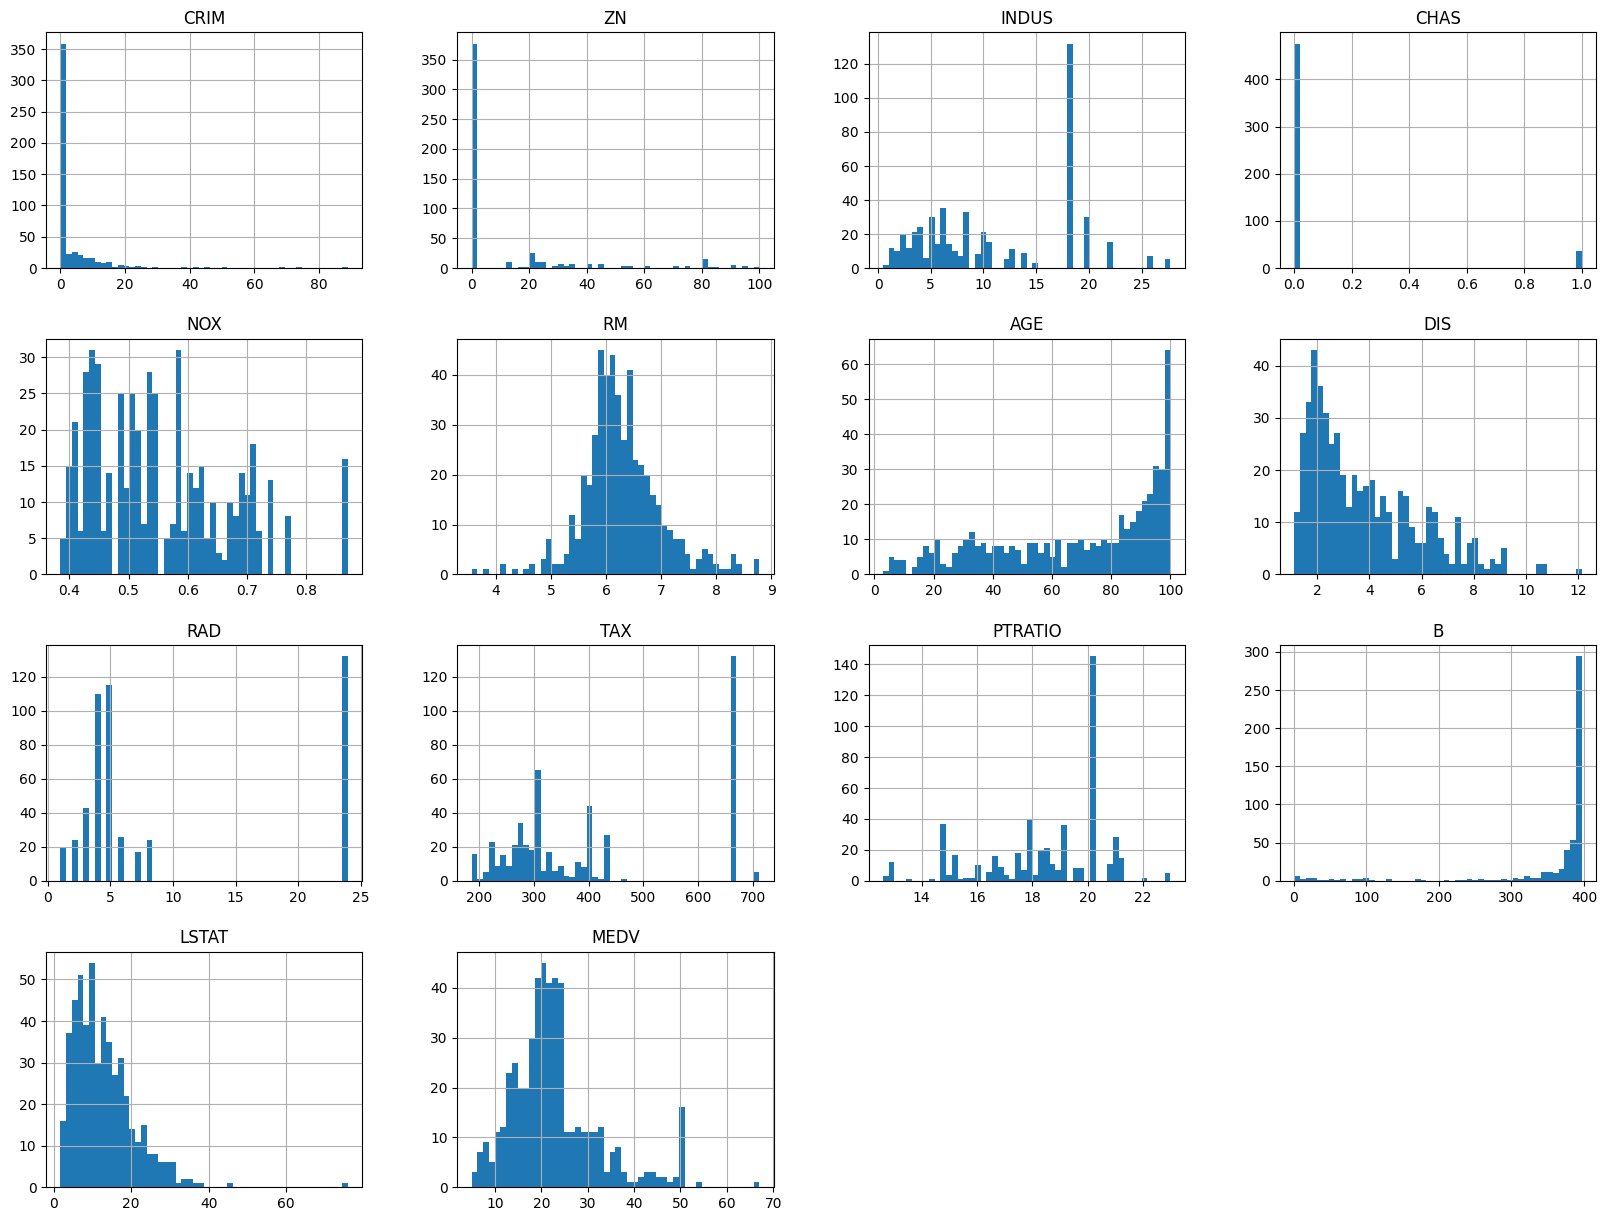

In [8]:
housing.hist(bins=50, figsize=(20,15))

### **Train-Test Splitting**

**This is manual train-test split**

In [9]:
def split_train_test(data, test_ratio):
    shuffled = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled[:test_set_size]
    train_indices = shuffled[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

### **This is predefined sklearn train-test split**

In [10]:
X =housing.drop(columns=["MEDV"])
y= housing['MEDV']

X_train, X_test, y_train , y_test = train_test_split(X,y, test_size=0.2, random_state = 42, shuffle= True)


In [11]:
len(X_train)

408

In [12]:
len(X_test)

103

### **Looking for Corelations**

In [13]:
corr_matrix = housing.corr()

In [14]:
corr_matrix['MEDV'].sort_values(ascending=False)

MEDV       1.000000
RM         0.665923
ZN         0.339767
B          0.317941
DIS        0.233469
CHAS       0.164782
AGE       -0.368203
RAD       -0.379016
CRIM      -0.380072
NOX       -0.411486
PTRATIO   -0.447464
TAX       -0.459274
INDUS     -0.463269
LSTAT     -0.562960
Name: MEDV, dtype: float64

### **Visualizing Attributes**

array([[<Axes: xlabel='MEDV', ylabel='MEDV'>,
        <Axes: xlabel='RM', ylabel='MEDV'>,
        <Axes: xlabel='ZN', ylabel='MEDV'>,
        <Axes: xlabel='LSTAT', ylabel='MEDV'>],
       [<Axes: xlabel='MEDV', ylabel='RM'>,
        <Axes: xlabel='RM', ylabel='RM'>,
        <Axes: xlabel='ZN', ylabel='RM'>,
        <Axes: xlabel='LSTAT', ylabel='RM'>],
       [<Axes: xlabel='MEDV', ylabel='ZN'>,
        <Axes: xlabel='RM', ylabel='ZN'>,
        <Axes: xlabel='ZN', ylabel='ZN'>,
        <Axes: xlabel='LSTAT', ylabel='ZN'>],
       [<Axes: xlabel='MEDV', ylabel='LSTAT'>,
        <Axes: xlabel='RM', ylabel='LSTAT'>,
        <Axes: xlabel='ZN', ylabel='LSTAT'>,
        <Axes: xlabel='LSTAT', ylabel='LSTAT'>]], dtype=object)

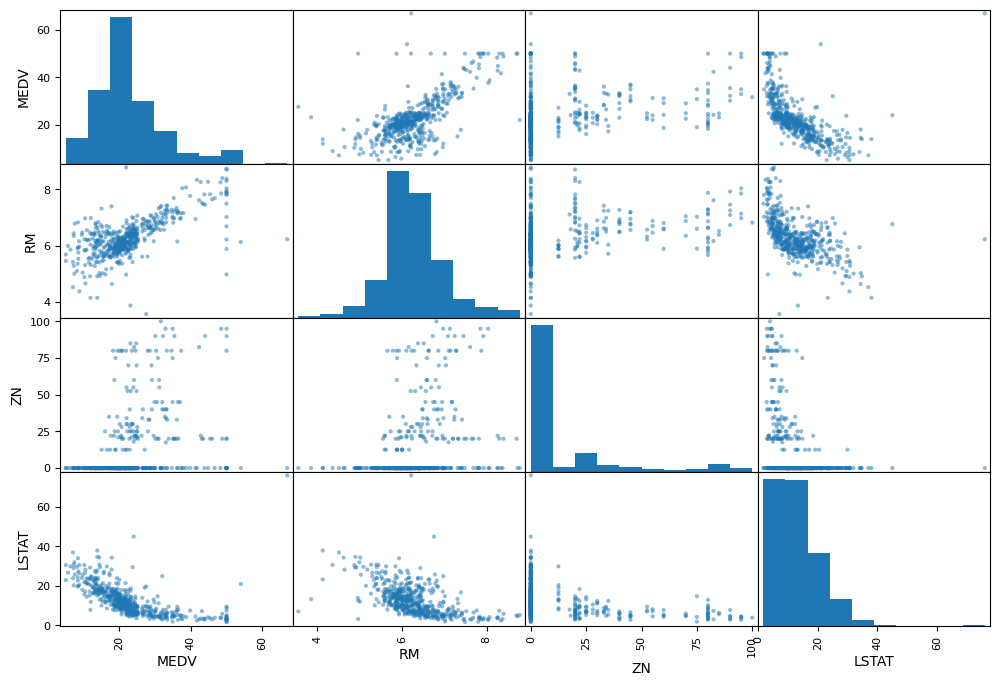

In [15]:

attributes = ['MEDV','RM','ZN','LSTAT']
scatter_matrix(housing[attributes], figsize=(12,8))

### **PLOTTING DATA IN SCATTER TO DETERMINE WHICH DATA IS NOT IMPORTANT**

<Axes: xlabel='RM', ylabel='MEDV'>

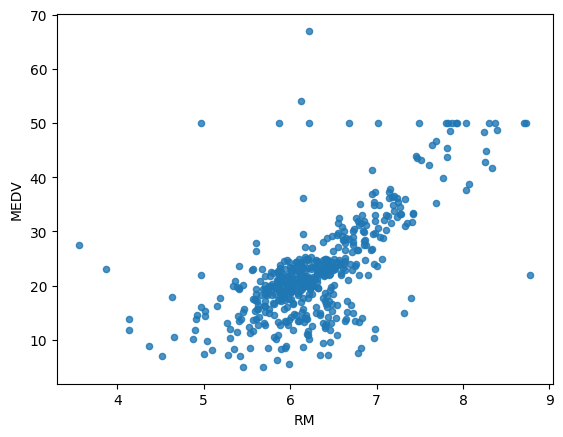

In [16]:
housing.plot(kind="scatter", x="RM", y="MEDV", alpha=0.8)

### **Trying Attribute Combination**

In [17]:
housing['TPR'] = housing['TAX']/housing['RM']

In [18]:
housing.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,TPR
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,45.019011
1,0.02731,0.0,7.07,0,0.469,NaN,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,NaN
2,0.02729,0.0,7.07,0,0.469,NaN,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,NaN
3,0.03237,0.0,2.18,0,0.458,NaN,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,NaN
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,31.061984


In [19]:
corr_matrix = housing.corr()
corr_matrix['MEDV'].sort_values(ascending=False)

MEDV       1.000000
RM         0.665923
ZN         0.339767
B          0.317941
DIS        0.233469
CHAS       0.164782
AGE       -0.368203
RAD       -0.379016
CRIM      -0.380072
NOX       -0.411486
PTRATIO   -0.447464
TAX       -0.459274
INDUS     -0.463269
TPR       -0.526364
LSTAT     -0.562960
Name: MEDV, dtype: float64

<Axes: xlabel='TPR', ylabel='MEDV'>

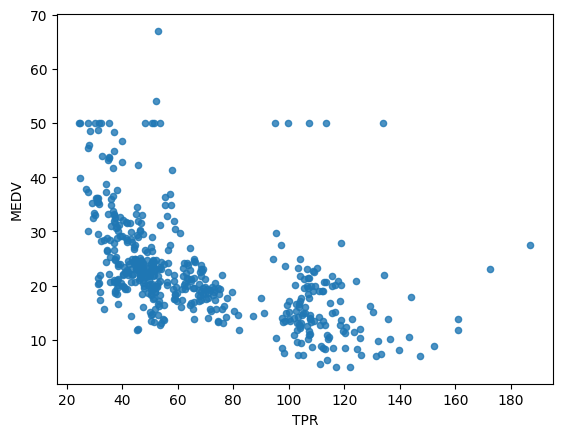

In [20]:
housing.plot(kind="scatter", x="TPR", y="MEDV", alpha=0.8)

### **Missing Attributes:**

#### **Handling Missing Attributes**

**When dealing with missing data in a dataset, there are three common approaches:**

### **1. Remove Missing Values (Rows)**
- **Delete the entire row that contains missing values.**
- **Use when:**
  - **The dataset is large.**
  - **Only a small number of rows have missing values.**
- **Pros:**
  - **Simple and quick.**
- **Cons:**
  - **Loss of potentially useful data.**

---

### **2. Remove the Entire Attribute (Column)**
- **Delete the whole column that has many missing values.**
- **Use when:**
  - **The attribute has too many missing entries.**
  - **The attribute is not very important.**
- **Pros:**
  - **Keeps dataset clean and consistent.**
- **Cons:**
  - **Loss of an entire feature that might carry useful information.**

---

### **3. Fill Missing Values (Imputation)**
- **Replace missing values with a specific value such as:**
  - **0**
  - **Mean**
  - **Median**
  - **Mode**
- **Use when:**
  - **You want to retain all data.**
- **Pros:**
  - **Preserves dataset size.**
- **Cons:**
  - **May introduce bias if not done carefully.**


#### **Option 1:**

In [21]:
a= housing.dropna(subset=['RM']) #This is Option 1
a.shape

(502, 15)

#### **Option 2:**

In [22]:
b = housing.drop("RM",axis=1) ## This is Option 2
b.shape

##The Original Dtaset is still unchanged!

(511, 14)

#### **Option 3:**

In [23]:
median = housing['RM'].median()
housing['RM'].fillna(median)
housing.shape


(511, 15)

#### **Imputation:**

In [24]:
imputer = SimpleImputer(strategy= "median")
imputer.fit(housing)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [25]:
imputer.statistics_

array([2.61690000e-01, 0.00000000e+00, 9.69000000e+00, 0.00000000e+00,
       5.38000000e-01, 6.20850000e+00, 7.73000000e+01, 3.15230000e+00,
       5.00000000e+00, 3.30000000e+02, 1.91000000e+01, 3.91340000e+02,
       1.14500000e+01, 2.12000000e+01, 5.36068119e+01])

In [28]:
X = imputer.transform(housing)

In [30]:
housing_tr = pd.DataFrame(X, columns=housing.columns)
housing_tr.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,TPR
count,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000
mean,3.584139,11.252446,11.151096,0.068493,0.554757,6.283451,68.616243,3.783876,9.485323,407.440313,18.500000,356.600900,12.879550,22.682192,66.723719
std,8.564433,23.234838,6.828175,0.252838,0.115310,0.698388,28.099130,2.098631,8.688469,167.903532,2.200348,90.882679,7.797416,9.484262,31.131043
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000,24.645639
25%,0.082325,0.000000,5.190000,0.000000,0.449000,5.887500,45.050000,2.100350,4.000000,279.500000,17.400000,374.710000,7.065000,17.050000,44.598431
50%,0.261690,0.000000,9.690000,0.000000,0.538000,6.208500,77.300000,3.152300,5.000000,330.000000,19.100000,391.340000,11.450000,21.200000,53.606812
75%,3.621175,12.500000,18.100000,0.000000,0.624000,6.618500,94.050000,5.118000,24.000000,666.000000,20.200000,396.210000,17.105000,25.000000,97.532443
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,23.000000,396.900000,76.000000,67.000000,187.026116


#### **Scikit-Learn Design**

##### **There are primarily three types of objects:**

**1. Estimators - It estimates some paremeters E.g Imputers. It has a fit method and transform method. Fit Method - It fits ddataset and calculates internal parameters**\

**2. Transformers - Transform method takes input and returns output based on the learnings of the fit(). It also has a convinence function called fit_transform()**\

**3. Predictors - LinearRegression Model is an example of predictor. fit() and predict() are two common functions. It also give score() function which will evaluate the predictors.** 

#### **Feature Scaling**

**Primarily Two types of feature scaling methods:**\
**1. Min-Max scaling (Normalization)**

#### **Creating a Pipeline**